/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

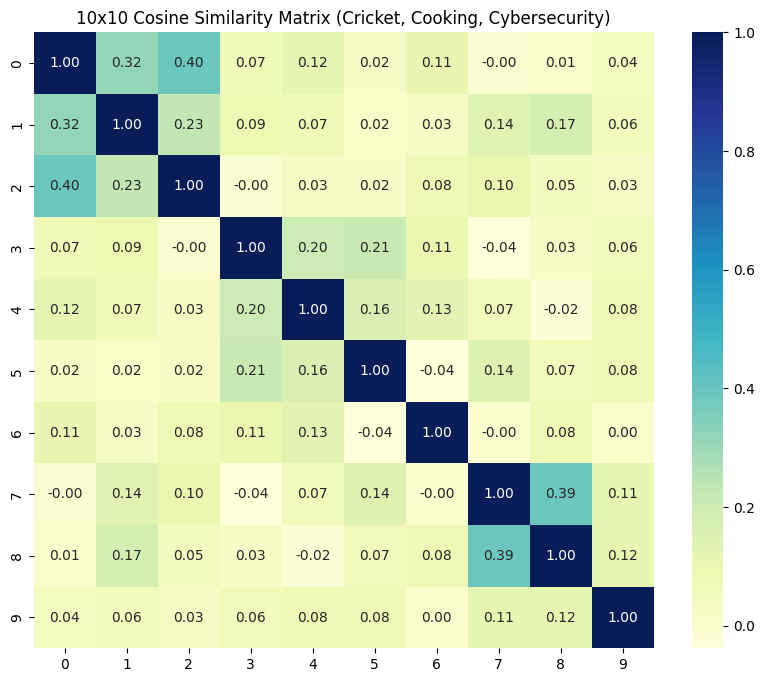

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

sentences = [
    "The opening batsman hit a magnificent century in the first innings.",
    "A spin bowler can use the pitch conditions to deceive the opponent.",
    "The fielder made an incredible catch at the boundary to save a six.",
    "Sauté the onions until they are golden brown before adding the spices.",
    "Slow-cooking meat at a low temperature ensures it remains tender and juicy.",
    "A pinch of saffron can drastically enhance the aroma of the biryani.",
    "Baking bread from scratch requires patience and precise measurements.",
    "Multi-factor authentication adds an essential layer of security to accounts.",
    "Phishing attacks often use deceptive emails to steal sensitive user data.",
    "Regular software updates are critical to patching known vulnerabilities."
]

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences, convert_to_tensor=True)

cosine_scores = util.cos_sim(embeddings, embeddings).cpu().numpy()

plt.figure(figsize=(10, 8))
sns.heatmap(cosine_scores, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('10x10 Cosine Similarity Matrix (Cricket, Cooking, Cybersecurity)')
plt.show()

In [3]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

similarities = util.cos_sim(query_embedding, embeddings)[0]

top_results = np.argsort(-similarities)[:2]

print(f"Query: {query}\n")
print("Top 2 most similar sentences:")
for idx in top_results:
    print(f"- {sentences[idx]} (Score: {similarities[idx]:.4f})")

Query: The bowler took three wickets in one over

Top 2 most similar sentences:
- The opening batsman hit a magnificent century in the first innings. (Score: 0.5296)
- A spin bowler can use the pitch conditions to deceive the opponent. (Score: 0.4910)
